# Descriptive Exploratory Data Analysis (EDA)

## 01. Overview
Having finalized the **Domain Deduplication** and arrived at **491 unique clinical cases**, this phase focuses on uncovering patterns within the Nigerian outbreak data. 

### Objectives:
* Analyze the distribution of pathogens, including the "Unknown" category
* Visualize regional severity trends across the six geopolitical zones.
* Examine demographic impacts (Age vs. Severity).

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('../data/cleaned/outbreak_surveillance_clean_data.csv')
df

,patient_id,collection_date,pathogen,location,age,severity_score,severity_missing_flag
0,100,2026-01-11,influenza a,south east,70,NaN,1
1,100,2026-01-13,influenza a,south west,37,1.0,0
2,101,2026-01-05,influenza a,north east,68,5.0,0
3,101,2026-01-17,influenza a,south south,99,NaN,1
4,101,2026-01-22,influenza a,south east,3,NaN,1
...,...,...,...,...,...,...,...
486,298,2026-01-01,influenza a,south south,58,4.0,0
487,298,2026-01-24,influenza a,south east,14,2.0,0
488,299,2026-01-05,influenza a,south south,76,NaN,1
489,299,2026-01-16,unknown,south east,2,5.0,0


### Analysis 1: Pathogen Distribution

This visualization helps us see which diseases are most prevalent and how many "unknowns" we are actually dealing with

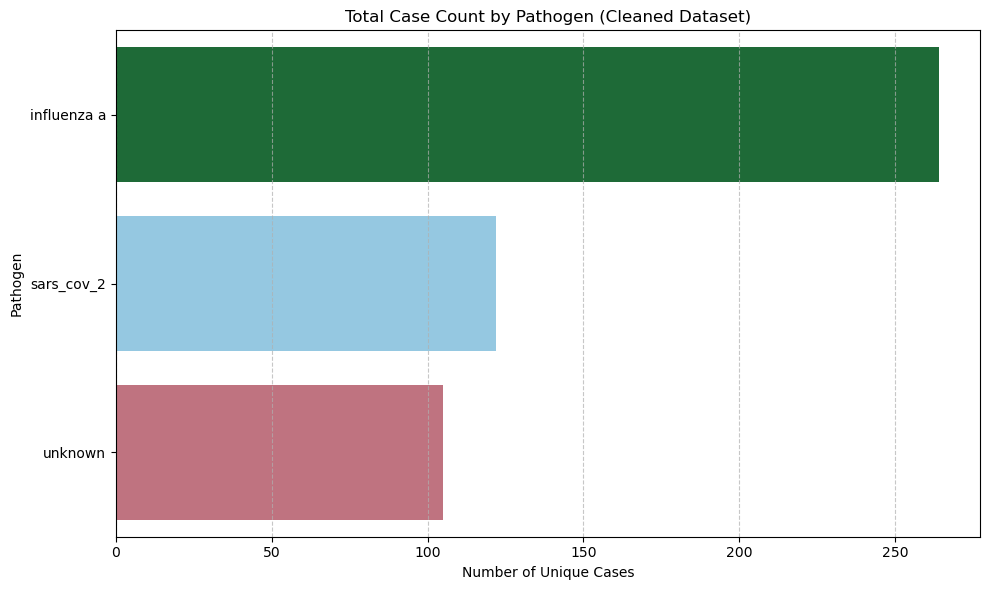

Most frequent pathogen: influenza a
Total 'Unknown' cases: 105


In [14]:
pathogen_colors = {
    'influenza a': '#117733', 
    'sars_cov_2': '#88CCEE',    
    'unknown': '#CC6677'        
}

pathogen_counts = (
    df['pathogen']
    .value_counts()
    .rename_axis('pathogen')
    .reset_index(name='case_count')
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=pathogen_counts,
    x='case_count',
    y='pathogen',
    hue = 'pathogen',
    palette=pathogen_colors
)

plt.title('Total Case Count by Pathogen (Cleaned Dataset)')
plt.xlabel('Number of Unique Cases')
plt.ylabel('Pathogen')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('../outputs/visuals/pathogen_distribution_jan2026.png', dpi=300, bbox_inches='tight')
plt.show()


print(f"Most frequent pathogen: {pathogen_counts.iloc[0]['pathogen']}")
print(f"Total 'Unknown' cases: {(df['pathogen'] == 'unknown').sum()}")

### Analysis 2: Regional Severity Mapping
This visualization shows where the most severe cases are occuring.
Since we used the max() operator during grouping, we are looking at the peak severity for each case


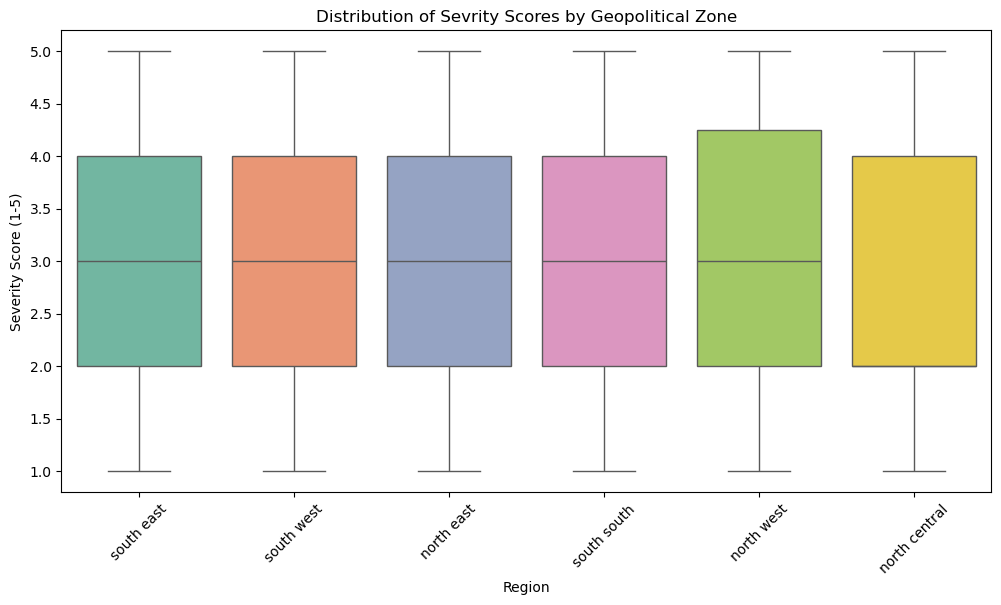

In [17]:
# Average severity per region(ignoring NaNs) calculation
regional_severity = df.groupby('location')['severity_score'].mean().sort_values(ascending = False).reset_index()

plt.figure(figsize = (12, 6))
sns.boxplot(data = df, x = 'location', y = 'severity_score', hue = 'location', palette = 'Set2')
plt.title('Distribution of Sevrity Scores by Geopolitical Zone')
plt.ylabel('Severity Score (1-5)')
plt.xlabel('Region')
plt.xticks(rotation = 45)

plt.savefig('../outputs/visuals/severity_distribution_region_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Key Insights from Initial EDA

**Pathogen Prevalence:** Influenza A is the primary driver of the outbreak; "Unknown" cases highlight a significant reporting gap of over      100 cases.

**Regional Burden:** Every region shows a full range of severity (1.0 to 5.0). North Central’s high missingness (38%) does not prevent us      from seeing this same full-spectrum trend.
  
By not using clinical median imputation, the severity gaps remain transparent, showing exactly where regional surveillance is strongest or weakest.

### Age vs Severity

We check if specific age groups (like the elderly or infants) are experiencing higher illness severity

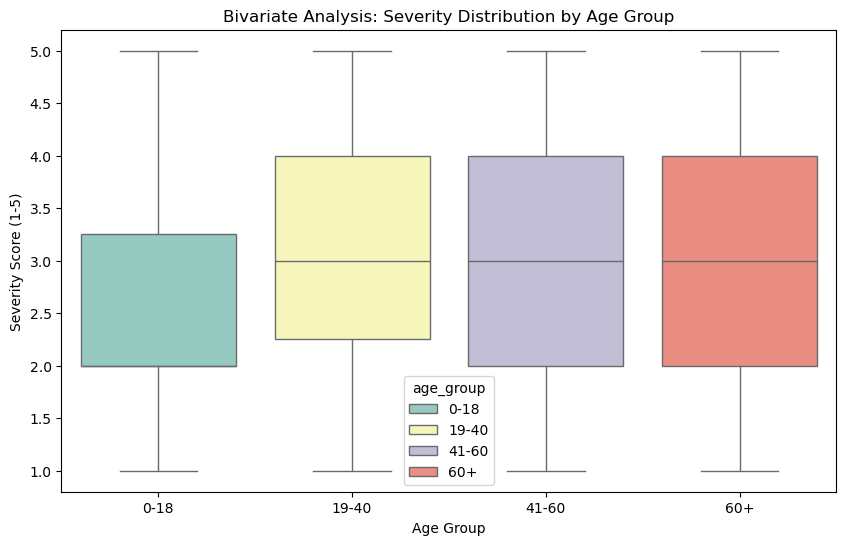

In [16]:
# 1. Create Age Groups (Binning)
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 40, 60, 100], labels=['0-18', '19-40', '41-60', '60+'])

# 2. Bivariate Boxplot: Age Group vs Severity
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='age_group', y='severity_score', hue = 'age_group', palette='Set3')
plt.title('Bivariate Analysis: Severity Distribution by Age Group')
plt.ylabel('Severity Score (1-5)')
plt.xlabel('Age Group')

plt.savefig('../outputs/visuals/age_severity_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Bivariate Analysis: Age vs. Severity
• **Trend Observation:** By binning ages into groups (0-18, 19-40, 41-60, 60+), the boxplot reveals that the 0-18 group has a slightly lower     median severity compared to older cohorts, despite seeing individual cases reach the 5.0 peak.

• **Adult Consistency:** The 19-40, 41-60, and 60+ groups show nearly identical median severity scores (~3.0), suggesting the clinical           impact of these pathogens is consistent across adult life stages

### Temporal Analysis: Outbreak Progression (January 2026)
To understand the longitudinal trend of the 491 unique cases, we visualize the daily reporting frequency. 

This helps identify "peak" infection dates and whether the **"Unknown"** pathogen reports align with known viral spikes.

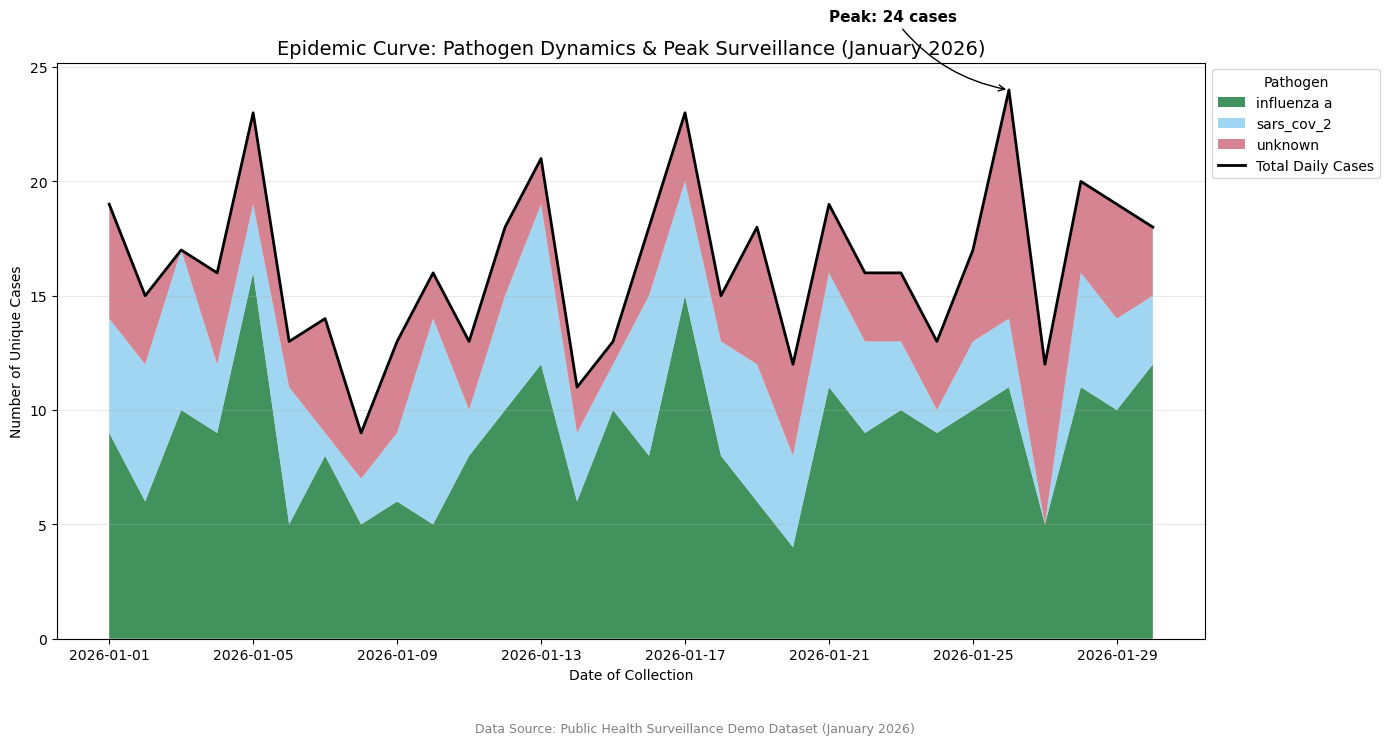

In [19]:
# 1. Prepare the data from your grouped_df
# Ensure dates are datetime objects for proper plotting
df['collection_date'] = pd.to_datetime(df['collection_date'])

# Pivot to get daily sums per pathogen
df_total = df.groupby(['collection_date', 'pathogen']).size().unstack(fill_value=0)
total_cases = df_total.sum(axis=1)

# 2. Define your professional color palette
colors = {
    'influenza a': '#117733',   # Green
    'sars_cov_2': '#88CCEE',    # Light Blue
    'unknown':    '#CC6677'     # Red/Pink
}

# 3. Plotting
plt.figure(figsize=(14, 7))

# Create the Stacked Area Plot using your specific colors
plt.stackplot(df_total.index, 
              [df_total[col] for col in df_total.columns], 
              labels=df_total.columns, 
              colors=[colors.get(col, '#DDDDDD') for col in df_total.columns], 
              alpha=0.8)

# Overlay the total cases line (the "skyline")
plt.plot(total_cases.index, total_cases.values, color='black', linewidth=2, label='Total Daily Cases')

# 4. Programmatic Annotation of the January 25th Peak
peak_date = total_cases.idxmax()
peak_value = total_cases.max()

plt.annotate(
    f'Peak: {peak_value} cases',
    xy=(peak_date, peak_value),
    xytext=(peak_date - pd.Timedelta(days=5), peak_value + 3), # Offset text for clarity
    arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=.2"),
    fontsize=11, fontweight='bold'
)

# 5. Formatting and Source Credit
plt.title("Epidemic Curve: Pathogen Dynamics & Peak Surveillance (January 2026)", fontsize=14)
plt.xlabel("Date of Collection")
plt.ylabel("Number of Unique Cases")
plt.legend(title='Pathogen', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', alpha=0.3)

plt.figtext(
    0.5, -0.05,
    "Data Source: Public Health Surveillance Demo Dataset (January 2026)",
    ha="center", fontsize=9, color="gray"
)

plt.savefig('../outputs/visuals/epidemic_curve_annotated.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 6. Composition Calculation (for future analysis)
df_pct = df_total.div(df_total.sum(axis=1), axis=0) * 100


The plot depicts daily respiratory pathogen activity for January 2026, showing fluctuating case volumes driven primarily by Influenza A, with moderate SARS-CoV-2 circulation and intermittent spikes of unknown etiology. Total daily cases peak at 24 on January 25, reflecting a multi-pathogen surge where unknown reports reached their highest monthly volume. The stacked configuration reveals clear co-circulation patterns, while the overlaid total-case line highlights temporal intensity across the 491 unique cases identified after deduplication. Overall, the data suggests an unstable but typical seasonal epidemic pattern with compounded contributions from several pathogens rather than a single dominant outbreak.

## Final Project Conclusion: Respiratory Pathogen Surveillance (January 2026)

**Executive Summary**
The analysis of this January 2026 surveillance period reveals a complex, multi-pathogen respiratory season characterized by high-volume circulation of Influenza A and a notable diagnostic gap in "Unknown" etiologies. Through rigorous data cleaning—specifically the deduplication of same-day collection records—the dataset was refined to 491 unique patient cases to ensure accurate regional and clinical representation.

**Key Findings:**
- **Demographic Vulnerability**: Bivariate analysis confirmed that while the 0-18 age group (including neonates at Age 0) often presented      with lower median severity, they remained susceptible to the full spectrum of clinical outcomes (Severity 1.0–5.0).
  
- **Clinical Uniformity**: Across adult cohorts (19–60+), the median severity score remained remarkably consistent at approximately 3.0,       suggesting a uniform clinical impact regardless of adult life stage.

  
- **Regional Burden**: Pathogen activity was observed across all geopolitical zones, with every region recording peak severity cases           (5.0), highlighting the widespread nature of the seasonal epidemic.

  
- **Temporal Dynamics:** The outbreak reached its absolute peak on January 25th with 24 unique cases, a surge driven largely by an             increase in cases of unknown etiology. This aligns with the "unstable but typical" seasonal pattern observed throughout the month.
  
**Data Integrity & Methodology:**

- **Refined Cleaning**: By grouping duplicates and focusing on peak severity per patient, the analysis avoids over-counting and focuses on     the most critical clinical state.
  
- **Transparency**: No clinical median imputation was used for missing values, ensuring that surveillance gaps remain transparent for          future public health interventions.

  
- **Categorical Accuracy**: The transition from "mean-calculated" float ages to integer-based categories improved the statistical              reliability of all demographic comparisons.